# **1. Imports Library Umum & Konfigurasi Awal**

In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency
from tqdm.auto import tqdm
import joblib
from copy import deepcopy
import os
import shutil
import kagglehub
from google.colab import drive
from copy import deepcopy

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

# **2. Memuat Data**

## 2.1 Hubungkan Drive

In [ ]:
drive.mount('/content/drive', force_remount=True)
project_dir = "/content/drive/MyDrive/android-malware"

Mounted at /content/drive


## 2.2 Download Dataset

In [ ]:
downloaded_path = kagglehub.dataset_download("subhajournal/android-malware-detection")
print("Path to dataset files:", downloaded_path)

100%|██████████| 45.1M/45.1M [00:01<00:00, 28.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/subhajournal/android-malware-detection/versions/1


## 2.3 Pindahkan Data dan Set Path

In [ ]:
if not os.path.exists(project_dir):
    try:
        shutil.copytree(downloaded_path, project_dir)
        print("Dataset telah disalin secara permanen ke Google Drive")
    except Exception as e:
        print(f"Gagal menyalin data: {e}")
else:
    print("Folder project sudah ada di Drive.")

    csv_name = "Android_Malware.csv"
dataset_path = os.path.join(downloaded_path, csv_name)

Folder project sudah ada di Drive.


### 2.4 Cek Data

In [ ]:
# Membaca dataset
df = pd.read_csv(dataset_path)
print(f"Dataset berhasil dimuat dengan ukuran: {df.shape}\n")

target_column = 'Label'

print("DISTRIBUSI KELAS")
print(df[target_column].value_counts())

/tmp/ipykernel_5843/1341473938.py:2: DtypeWarning: Columns (56,58,63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


Dataset berhasil dimuat dengan ukuran: (355630, 86)

DISTRIBUSI KELAS
Label
Android_Adware         147443
Android_Scareware      117082
Android_SMS_Malware     67397
Benign                  23708
Name: count, dtype: int64


# **3. Exploratory Data Analysis (EDA)**


In [ ]:
TARGET_COLUMN = 'Label'
CATEGORICAL_COLS = None
DROP_COLS = None


## 3.1 Import Library untuk EDA dan Perprocesisng

In [ ]:
from scipy.stats import mannwhitneyu, chi2_contingency, shapiro, kruskal
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
print("Library berhasil diimport")


Library berhasil diimport


## 3.2 Info Dasar Dataset

In [ ]:
print("=" * 60)
print("TIPE DATA & NULL")
print("=" * 60)
info_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'null'    : df.isnull().sum(),
    'null_%'  : (df.isnull().sum() / len(df) * 100).round(2),
    'unique'  : df.nunique()
})
print(info_df.to_string())


TIPE DATA & NULL
                                dtype  null  null_%  unique
Unnamed: 0                      int64     0     0.0   14158
Flow ID                        object     1     0.0  176955
 Source IP                     object     0     0.0    2536
 Source Port                    int64     0     0.0   51343
 Destination IP                object     0     0.0    4746
 Destination Port             float64     0     0.0   19409
 Protocol                     float64     0     0.0       5
 Timestamp                     object     0     0.0   72218
 Flow Duration                  int64     0     0.0  266027
 Total Fwd Packets              int64     0     0.0     630
 Total Backward Packets         int64     0     0.0     960
Total Length of Fwd Packets   float64     0     0.0    9551
 Total Length of Bwd Packets  float64     0     0.0   24369
 Fwd Packet Length Max        float64     0     0.0    1414
 Fwd Packet Length Min        float64     0     0.0     210
 Fwd Packet Length Mean

## 3.3 Distribusi Kelas Target

                      Count  Percent (%)
Label                                   
Android_Adware       147443        41.46
Android_Scareware    117082        32.92
Android_SMS_Malware   67397        18.95
Benign                23708         6.67

Imbalance Ratio (max/min): 6.22x
Dataset cukup imbalanced (3–10x)


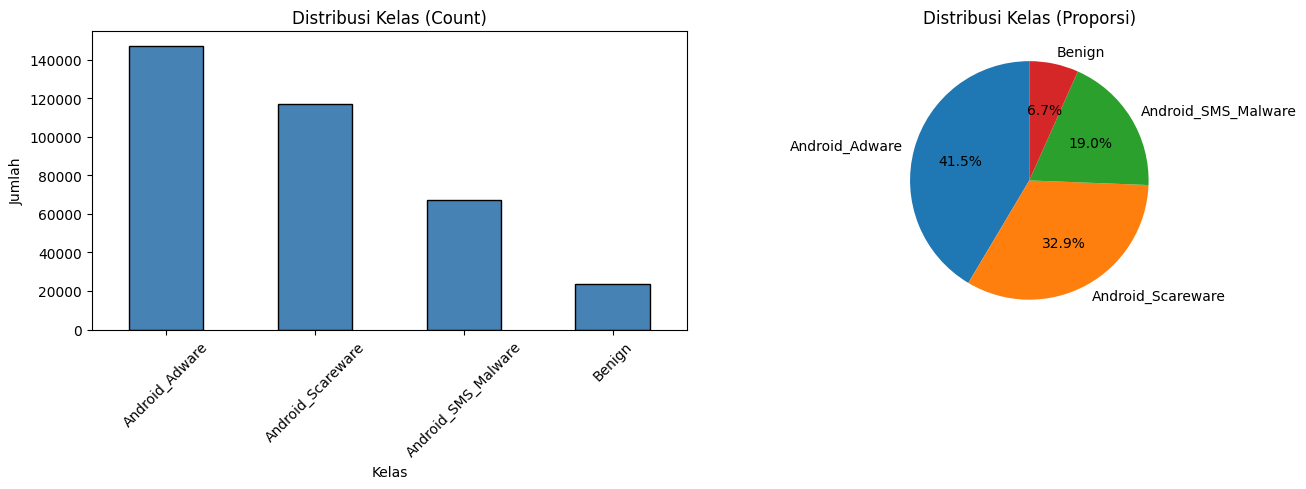

In [ ]:
vc = df[TARGET_COLUMN].value_counts()
vc_pct = df[TARGET_COLUMN].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': vc, 'Percent (%)': vc_pct.round(2)})
print(dist_df.to_string())

# Imbalance ratio
max_cls = vc.max()
min_cls = vc.min()
ratio   = max_cls / min_cls
print(f"\nImbalance Ratio (max/min): {ratio:.2f}x")
if ratio > 10:
    print("Dataset sangat imbalanced (>10x)")
elif ratio > 3:
    print("Dataset cukup imbalanced (3–10x)")
else:
    print("Dataset relatif balanced")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Kelas (Count)')
axes[0].set_xlabel('Kelas'); axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=45)

vc_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribusi Kelas (Proporsi)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight')
plt.show()


## 3.4 Duplikat & Missing Values

In [ ]:
dup = df.duplicated().sum()
null_total = df.isnull().sum().sum()
print(f"Baris duplikat : {dup} ({dup/len(df)*100:.2f}%)")
print(f"Total null     : {null_total}")

null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0].sort_values(ascending=False)
if len(null_cols):
    print("\nKolom dengan missing values:")
    print(null_cols.to_string())
else:
    print("Tidak ada missing values")


Baris duplikat : 2885 (0.81%)
Total null     : 117

Kolom dengan missing values:
 act_data_pkt_fwd           4
 min_seg_size_forward       4
Active Mean                 4
 Active Std                 4
 Active Max                 4
 Fwd Avg Packets/Bulk       4
Bwd Avg Bulk Rate           4
 Bwd Avg Packets/Bulk       4
 Bwd Avg Bytes/Bulk         4
 Fwd Avg Bulk Rate          4
Idle Mean                   4
 Idle Std                   4
 Idle Max                   4
 Active Min                 4
 Idle Min                   4
 Subflow Bwd Packets        4
 Subflow Fwd Bytes          4
Subflow Fwd Packets         4
 Subflow Bwd Bytes          4
Init_Win_bytes_forward      4
 Init_Win_bytes_backward    4
 Avg Bwd Segment Size       3
 Fwd Header Length.1        3
 Avg Fwd Segment Size       3
 Average Packet Size        3
Fwd Avg Bytes/Bulk          3
 ECE Flag Count             2
 Down/Up Ratio              2
 RST Flag Count             1
 SYN Flag Count             1
 Packet Length Std 

## 3.5 Statistik Deskriptif Fitur Numerik

In [ ]:
num_df = df.select_dtypes(include='number').drop(columns=[TARGET_COLUMN], errors='ignore')
desc = num_df.describe().T
desc['skewness'] = num_df.skew().round(3)
desc['kurtosis'] = num_df.kurt().round(3)
desc['cv (%)']   = (num_df.std() / num_df.mean().abs() * 100).round(2)
print(desc.to_string())


                                 count          mean           std           min           25%            50%           75%           max  skewness    kurtosis    cv (%)
Unnamed: 0                    355630.0  1.945719e+03  1.840478e+03  0.000000e+00    640.000000    1568.000000  2.718000e+03  1.415700e+04     2.588      10.935     94.59
 Source Port                  355630.0  3.914129e+04  1.794632e+04  0.000000e+00  34559.000000   43226.000000  5.228300e+04  1.045267e+06    -0.549      27.865     45.85
 Destination Port             355630.0  5.202541e+03  1.452135e+04  0.000000e+00     80.000000     443.000000  4.430000e+02  1.328159e+06     4.759     199.128    279.12
 Protocol                     355630.0  9.765190e+00  7.505412e+02  0.000000e+00      6.000000       6.000000  6.000000e+00  4.427197e+05   578.979  340562.602   7685.88
 Flow Duration                355630.0  1.092975e+07  2.180861e+07 -1.000000e+00  48886.000000  560225.500000  1.076907e+07  1.199999e+08     2.785   

## 3.6 Deteksi Outlier (IQR)

In [ ]:
num_df = df.select_dtypes(include='number').drop(columns=[TARGET_COLUMN], errors='ignore')

outlier_summary = []
for col in num_df.columns:
    Q1, Q3 = num_df[col].quantile(0.25), num_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((num_df[col] < Q1 - 1.5*IQR) | (num_df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'Feature': col, 'Outlier Count': outliers, 'Outlier %': round(outliers/len(df)*100, 2)})

out_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print(out_df[out_df['Outlier Count'] > 0].to_string(index=False))
print(f"\n{(out_df['Outlier Count'] == 0).sum()} fitur tanpa outlier")


                     Feature  Outlier Count  Outlier %
           Min Packet Length          80169      22.54
                    Protocol          78866      22.18
                 Fwd IAT Min          76773      21.59
       Bwd Packet Length Min          76177      21.42
           Subflow Bwd Bytes          75151      21.13
 Total Length of Bwd Packets          75152      21.13
      Packet Length Variance          75055      21.10
              URG Flag Count          72591      20.41
                 Bwd IAT Std          71351      20.06
                Bwd IAT Mean          71083      19.99
       Bwd Packet Length Std          70881      19.93
                 Fwd IAT Std          70593      19.85
       Bwd Packet Length Max          70345      19.78
               Bwd IAT Total          66651      18.74
                Flow IAT Min          65896      18.53
                 Bwd IAT Min          65893      18.53
                Flow IAT Std          65482      18.41
          

## 3.7 Korelasi Fitur Numerik

95 pasang fitur dengan korelasi > 0.9:
                   Feature A               Feature B  Correlation
           Total Fwd Packets     Subflow Fwd Packets       1.0000
 Total Length of Fwd Packets       Subflow Fwd Bytes       1.0000
      Total Backward Packets     Subflow Bwd Packets       1.0000
 Total Length of Bwd Packets       Subflow Bwd Bytes       1.0000
              SYN Flag Count          RST Flag Count       1.0000
           Fwd Header Length     Fwd Header Length.1       1.0000
              FIN Flag Count          RST Flag Count       1.0000
               Fwd URG Flags          SYN Flag Count       1.0000
               Bwd PSH Flags          SYN Flag Count       1.0000
               Bwd PSH Flags          FIN Flag Count       1.0000
               Fwd URG Flags          FIN Flag Count       1.0000
               Bwd PSH Flags           Fwd URG Flags       1.0000
               Bwd PSH Flags          RST Flag Count       1.0000
      Bwd Packet Length Mean    Avg B

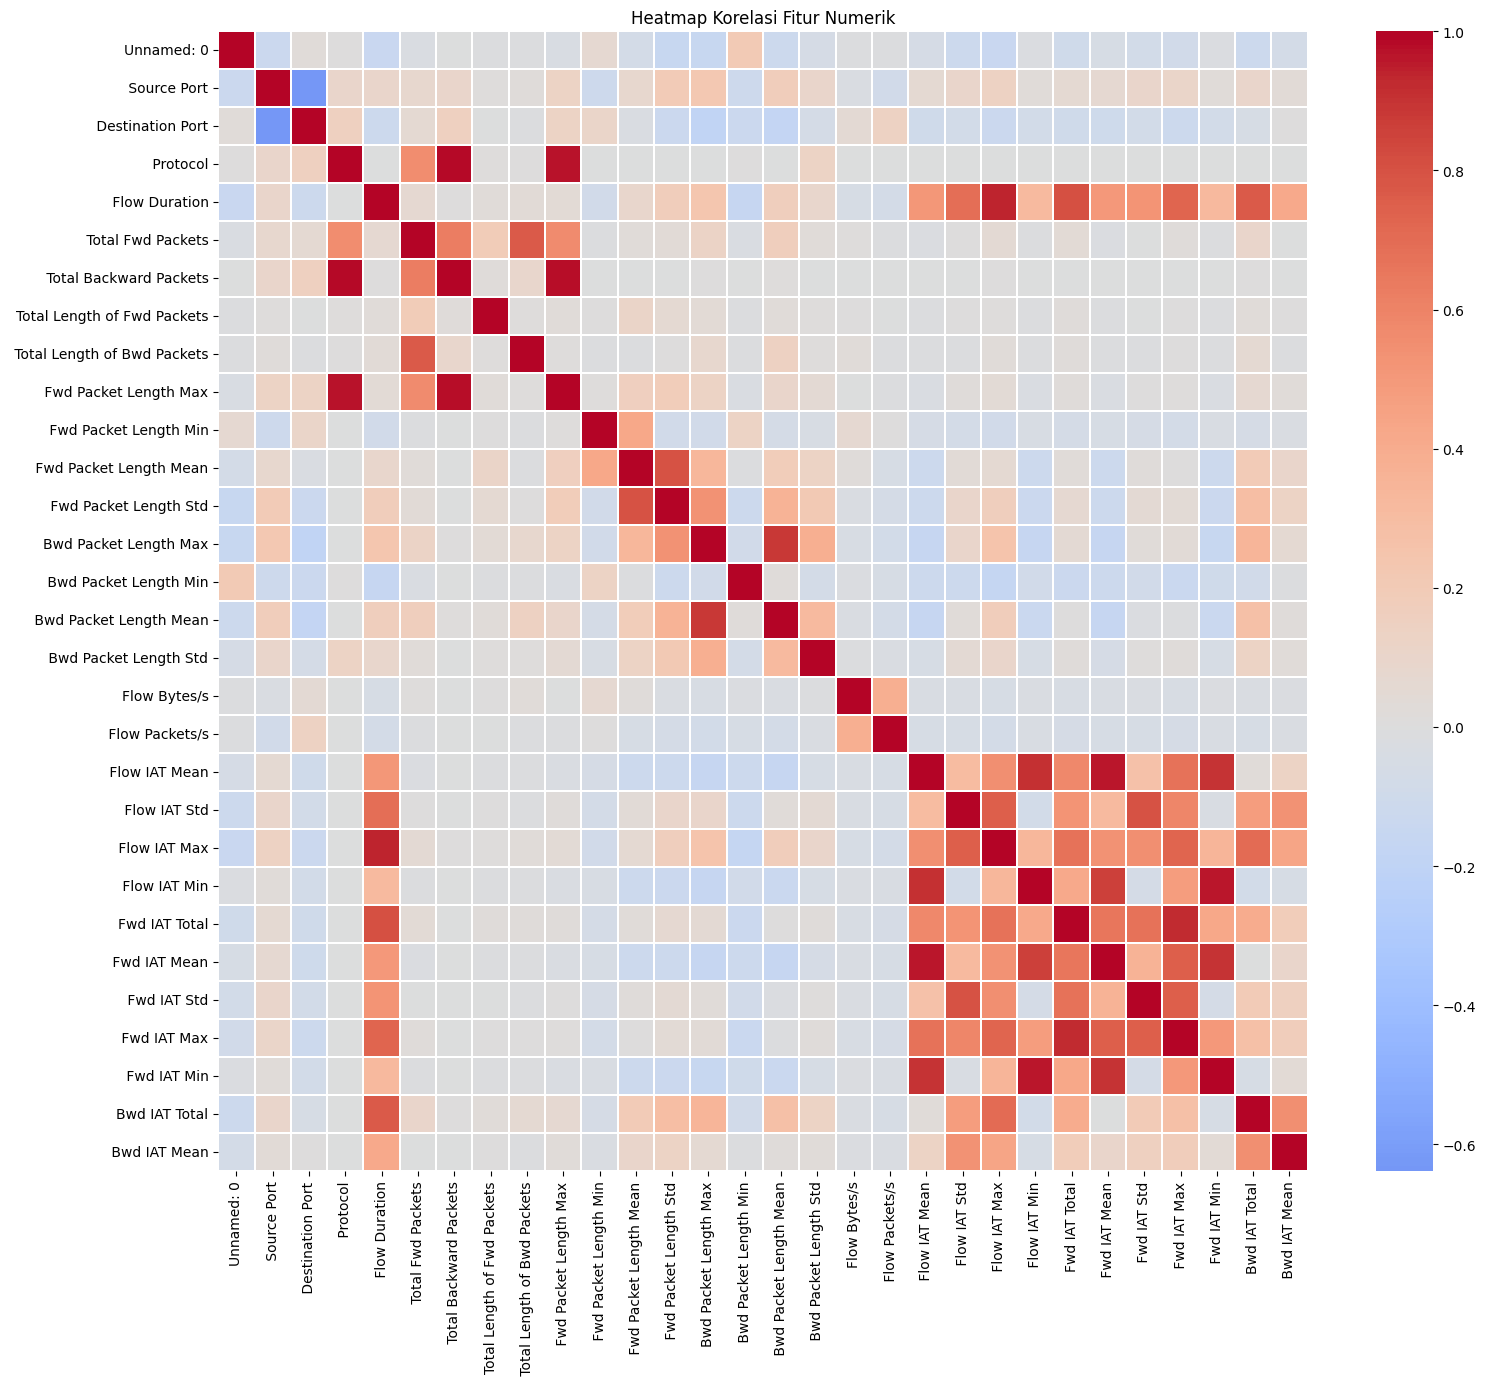

In [ ]:
num_df = df.select_dtypes(include='number').drop(columns=[TARGET_COLUMN], errors='ignore')
corr = num_df.corr()

high_corr = []
for i, j in combinations(corr.columns, 2):
    v = corr.loc[i, j]
    if abs(v) > 0.9:
        high_corr.append({'Feature A': i, 'Feature B': j, 'Correlation': round(v, 4)})

if high_corr:
    print(f"{len(high_corr)} pasang fitur dengan korelasi > 0.9:")
    print(pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False).to_string(index=False))
else:
    print("Tidak ada pasangan fitur dengan korelasi > 0.9")

# Heatmap
cols_plot = num_df.columns[:30]
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(num_df[cols_plot].corr(), cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True, ax=ax, linewidths=0.3)
ax.set_title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 3.8 Seleksi Fitur


In [ ]:
num_df = df.select_dtypes(include='number').drop(columns=[TARGET_COLUMN], errors='ignore')
kw_results = []
for col in num_df.columns:
    groups = [group[col].values for _, group in df.groupby(TARGET_COLUMN)]
    stat, p = kruskal(*groups)
    kw_results.append({'Feature': col, 'H-stat': round(stat, 4), 'p-value': p, 'Signifikan': p < 0.05})

kw_df = pd.DataFrame(kw_results).sort_values('p-value')
keep_num = kw_df[kw_df['Signifikan']]['Feature'].tolist()
drop_num = kw_df[~kw_df['Signifikan']]['Feature'].tolist()
print(f"Numerik dipertahankan : {len(keep_num)}")
print(f"Numerik dibuang       : {len(drop_num)} → {drop_num}")


if CATEGORICAL_COLS:
    cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]
else:
    cat_cols = df.select_dtypes(include='object').drop(columns=[TARGET_COLUMN], errors='ignore').columns.tolist()

chi_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET_COLUMN])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi_results.append({'Feature': col, 'Chi2': round(chi2, 4), 'p-value': p, 'Signifikan': p < 0.05})

if chi_results:
    chi_df = pd.DataFrame(chi_results).sort_values('p-value')
    keep_cat = chi_df[chi_df['Signifikan']]['Feature'].tolist()
    drop_cat = chi_df[~chi_df['Signifikan']]['Feature'].tolist()
    print(f"\nKategorikal dipertahankan : {len(keep_cat)}")
    print(f"Kategorikal dibuang       : {len(drop_cat)} → {drop_cat}")
else:
    keep_cat = []
    print("\nTidak ada kolom kategorikal yang dideteksi")

keep_features = keep_num + keep_cat
print(f"\nTotal fitur tersisa: {len(keep_features)}")


Numerik dipertahankan : 37
Numerik dibuang       : 41 → [' Bwd URG Flags', ' Fwd URG Flags', ' Bwd PSH Flags', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag Count', ' ECE Flag Count', ' Average Packet Size', ' Avg Fwd Segment Size', ' Avg Bwd Segment Size', ' Fwd Header Length.1', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', ' Subflow Fwd Bytes', ' Subflow Bwd Packets', ' Subflow Bwd Bytes', 'Init_Win_bytes_forward', ' Init_Win_bytes_backward', ' act_data_pkt_fwd', ' min_seg_size_forward', 'Active Mean', ' Active Std', ' Active Max', ' Active Min', 'Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min']

Kategorikal dipertahankan : 7
Kategorikal dibuang       : 0 → []

Total fitur tersisa: 44


## 3.9 Distribusi Fitur Numerik

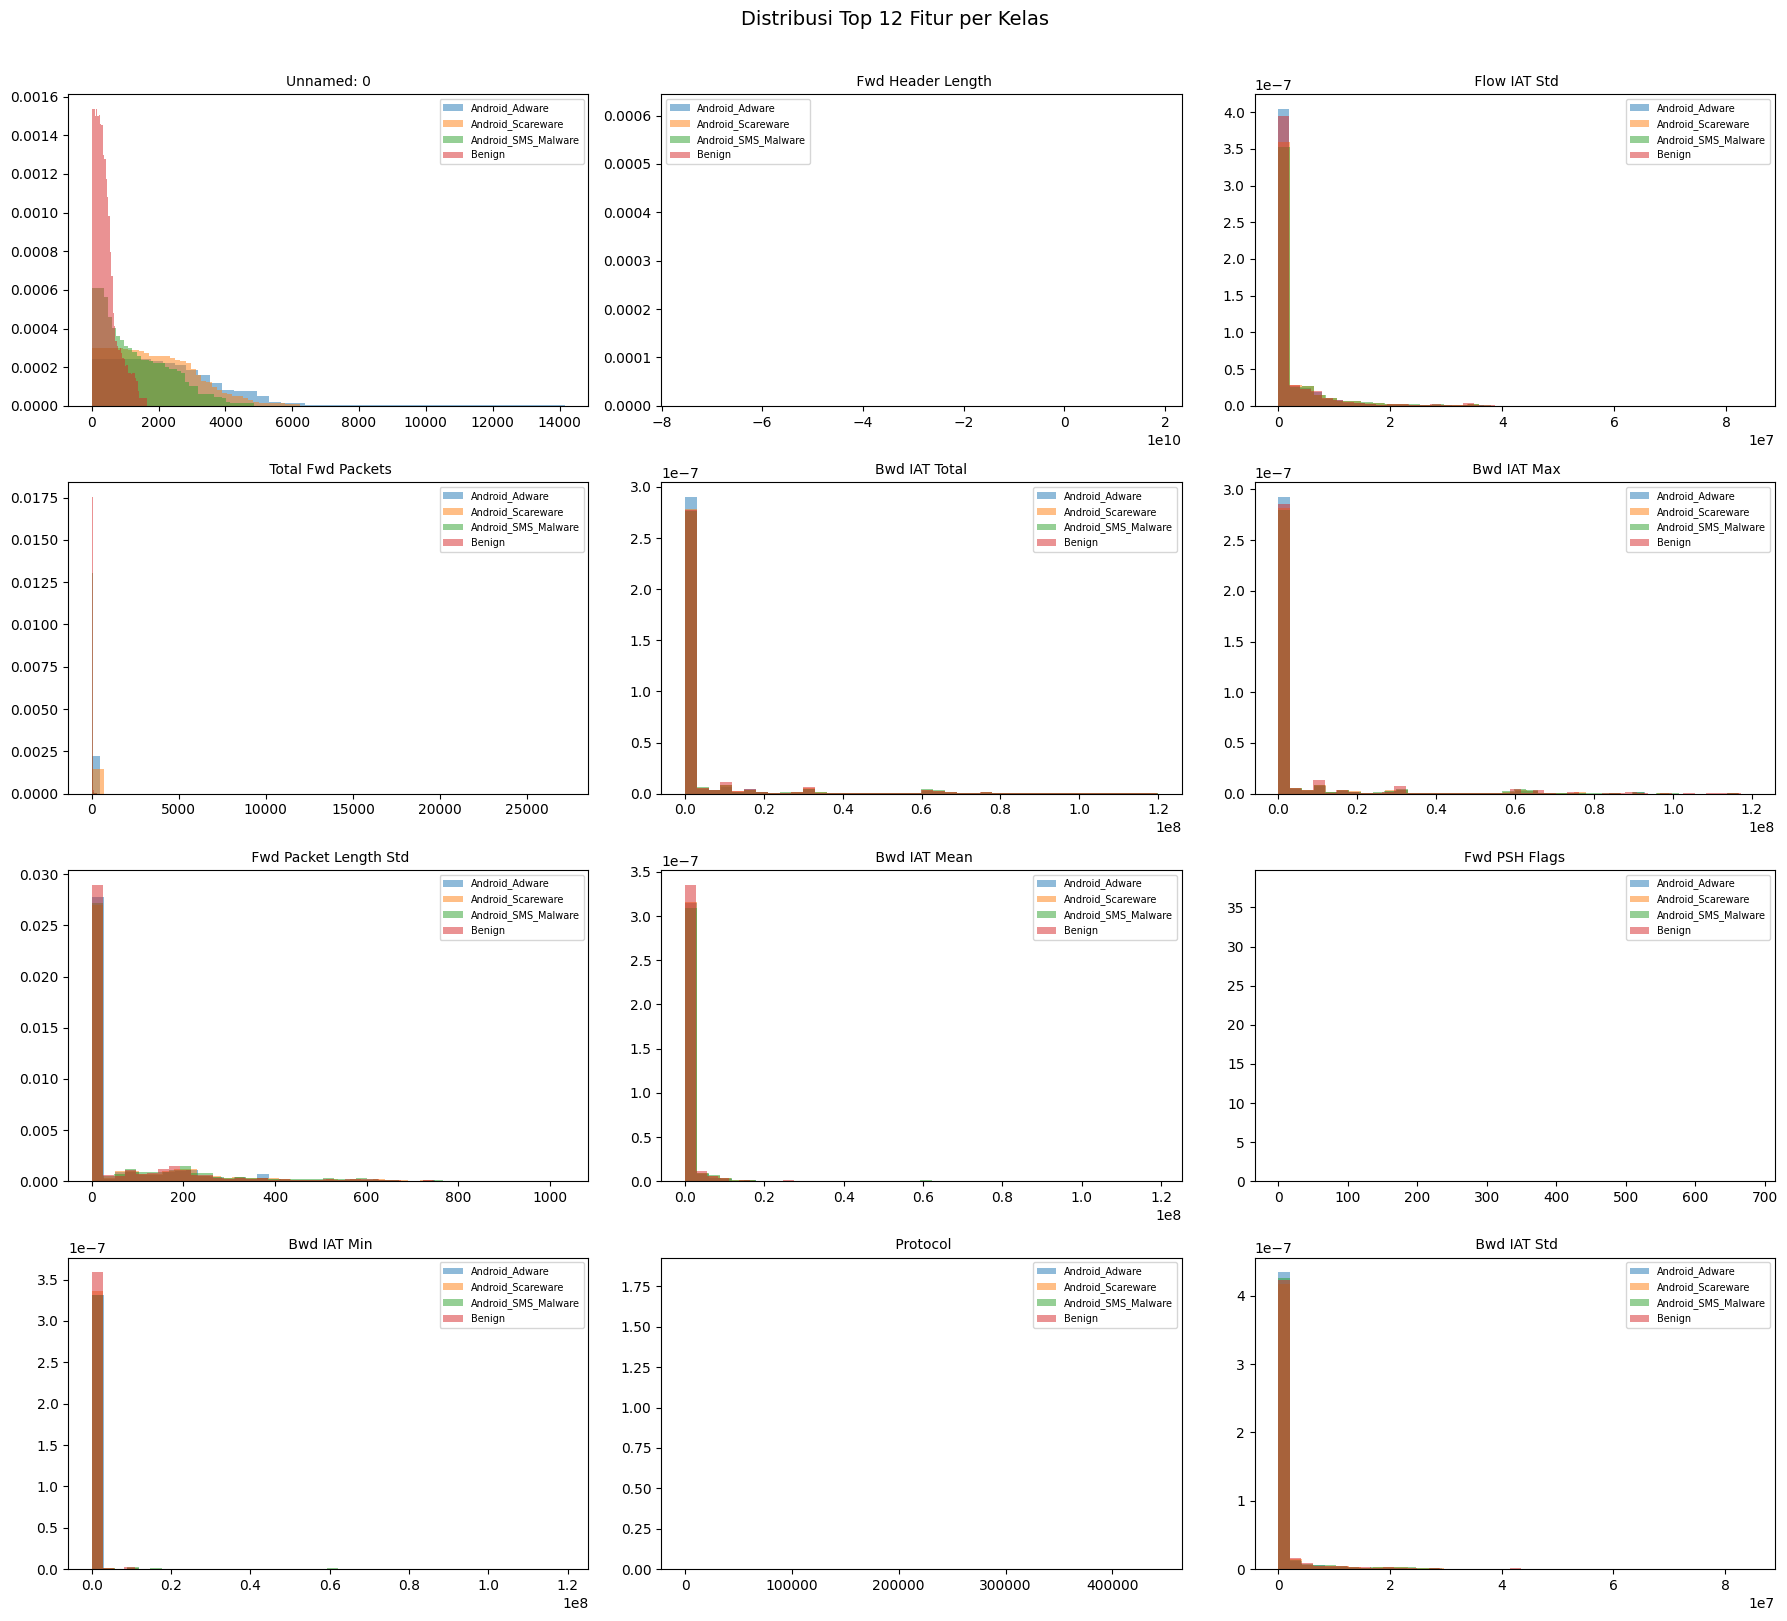

In [ ]:
top_feats = kw_df.sort_values('H-stat', ascending=False).head(12)['Feature'].tolist()

n = len(top_feats)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for idx, feat in enumerate(top_feats):
    for cls in df[TARGET_COLUMN].unique():
        subset = df[df[TARGET_COLUMN] == cls][feat]
        axes[idx].hist(subset, bins=40, alpha=0.5, label=str(cls), density=True)
    axes[idx].set_title(feat, fontsize=10)
    axes[idx].legend(fontsize=7)

for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribusi Top 12 Fitur per Kelas', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('04_feature_distribution_per_class.png', bbox_inches='tight')
plt.show()


# **4.Data Cleaning**

## 4.1 Membersihkan Spasi pada Nama Kolom

In [ ]:
df.columns = df.columns.str.strip()

## 4.2 Menghapus Kolom yang Tidak Diperlukan

In [ ]:
df = df.drop(columns=['Unnamed: 0','CWE Flag Count','Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk','Fwd Avg Bulk Rate',
                      'Bwd Avg Bytes/Bulk','Bwd Avg Packets/Bulk','Bwd Avg Bulk Rate','ECE Flag Count',
                      'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count',
                      'Timestamp', 'Flow ID'])

## 4.3 Menghapus Baris Berdasarkan Indeks

In [ ]:
df = df.drop(index=276556)

# **5. Penanganan Missing Values & Duplicates**

## 5.1 Pengecekan Ukuran Data Awal

In [ ]:
print("Original DataFrame:")
print(df.shape)

# Temukan baris yang mengandung setidaknya satu missing value
null_rows = df[df.isnull().any(axis=1)]

# Lihat baris yang akan dihapus
print("Rows to be dropped:")
print(null_rows.index)

Original DataFrame:
(355629, 71)
Rows to be dropped:
Index([262292, 285435, 323136], dtype='int64')


## 5.2 Hapus Baris Kosong & Duplikat

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

## 5.3 Pengecekan Ukuran Data Setelah Pembersihan

In [ ]:
print("Resulting DataFrame:")
print(df.shape)

Resulting DataFrame:
(351481, 71)


# **6. Konversi Tipe Data**

## 6.1 Konversi Kolom Numerik dan Integer

In [ ]:
# Konversi kolom ke tipe data numerik
df[['Protocol', 'Fwd PSH Flags', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count',
    'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio']] \
= df[['Protocol', 'Fwd PSH Flags', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count',
      'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio']].apply(pd.to_numeric)

# Konversi kolom numerik ke tipe data integer.
df[['Protocol', 'Fwd PSH Flags', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count',
    'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio']] \
= df[['Protocol', 'Fwd PSH Flags', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count',
      'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio']].astype(int)

### 6.2 Konversi Kolom Tertentu ke Object

In [ ]:
df[['Protocol','Fwd PSH Flags','FIN Flag Count','SYN Flag Count',
    'PSH Flag Count','ACK Flag Count','URG Flag Count']] \
= df[['Protocol','Fwd PSH Flags','FIN Flag Count','SYN Flag Count',
    'PSH Flag Count','ACK Flag Count','URG Flag Count']].astype('object')

# **7. Ekstraksi Fitur**

## 7.1 Konversi IP Address ke Desimal

In [ ]:
def ip_to_decimal(ip):
    octets = ip.split('.')
    binary = '{0:08b}{1:08b}{2:08b}{3:08b}'.format(*map(int, octets))
    decimal = int(binary, 2)
    return decimal

## 7.2 Penerapan Konversi IP ke Kolom Baru

In [ ]:
df['Source IP Decimal'] = df['Source IP'].apply(ip_to_decimal)
df['Destination IP Decimal'] = df['Destination IP'].apply(ip_to_decimal)

# **8. Encoding Target Multiclass & Pembersihan Akhir**

## 8.1 Import LabelEncoder & Cek Distribusi Label Asli

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
print("Distribusi label asli:")
print(df['Label'].value_counts())
print(f"\nTotal kelas: {df['Label'].nunique()}")

Distribusi label asli:
Label
Android_Adware         147427
Android_Scareware      117054
Android_SMS_Malware     63292
Benign                  23708
Name: count, dtype: int64

Total kelas: 4


## 8.2 Proses Label Encoding & Mapping Kelas

In [ ]:
# Encode label
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Label'])

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping kelas:")
for cls, idx in class_mapping.items():
    print(f"  {idx} = {cls}")

Mapping kelas:
  0 = Android_Adware
  1 = Android_SMS_Malware
  2 = Android_Scareware
  3 = Benign


## 8.3 Visualisasi Distribusi Kelas

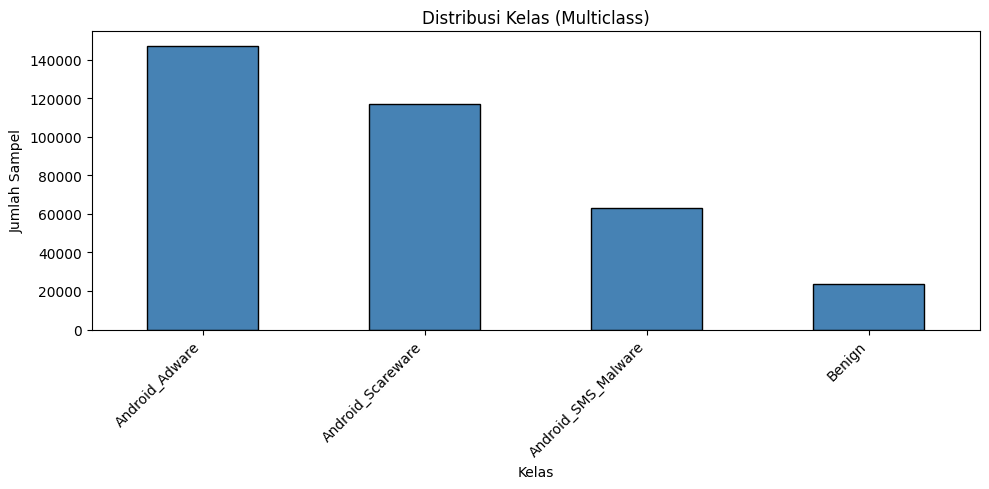

In [ ]:
plt.figure(figsize=(10, 5))
df['Label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kelas (Multiclass)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

## 8.4 Menghapus Kolom Asli Setelah Feature Engineering

In [ ]:
df = df.drop(columns=['Source IP', 'Destination IP', 'Label'])

# **9. Analisis Distribusi & Uji Statistik Fitur**

## 9.1 Visualisasi Histogram Distribusi Fitur

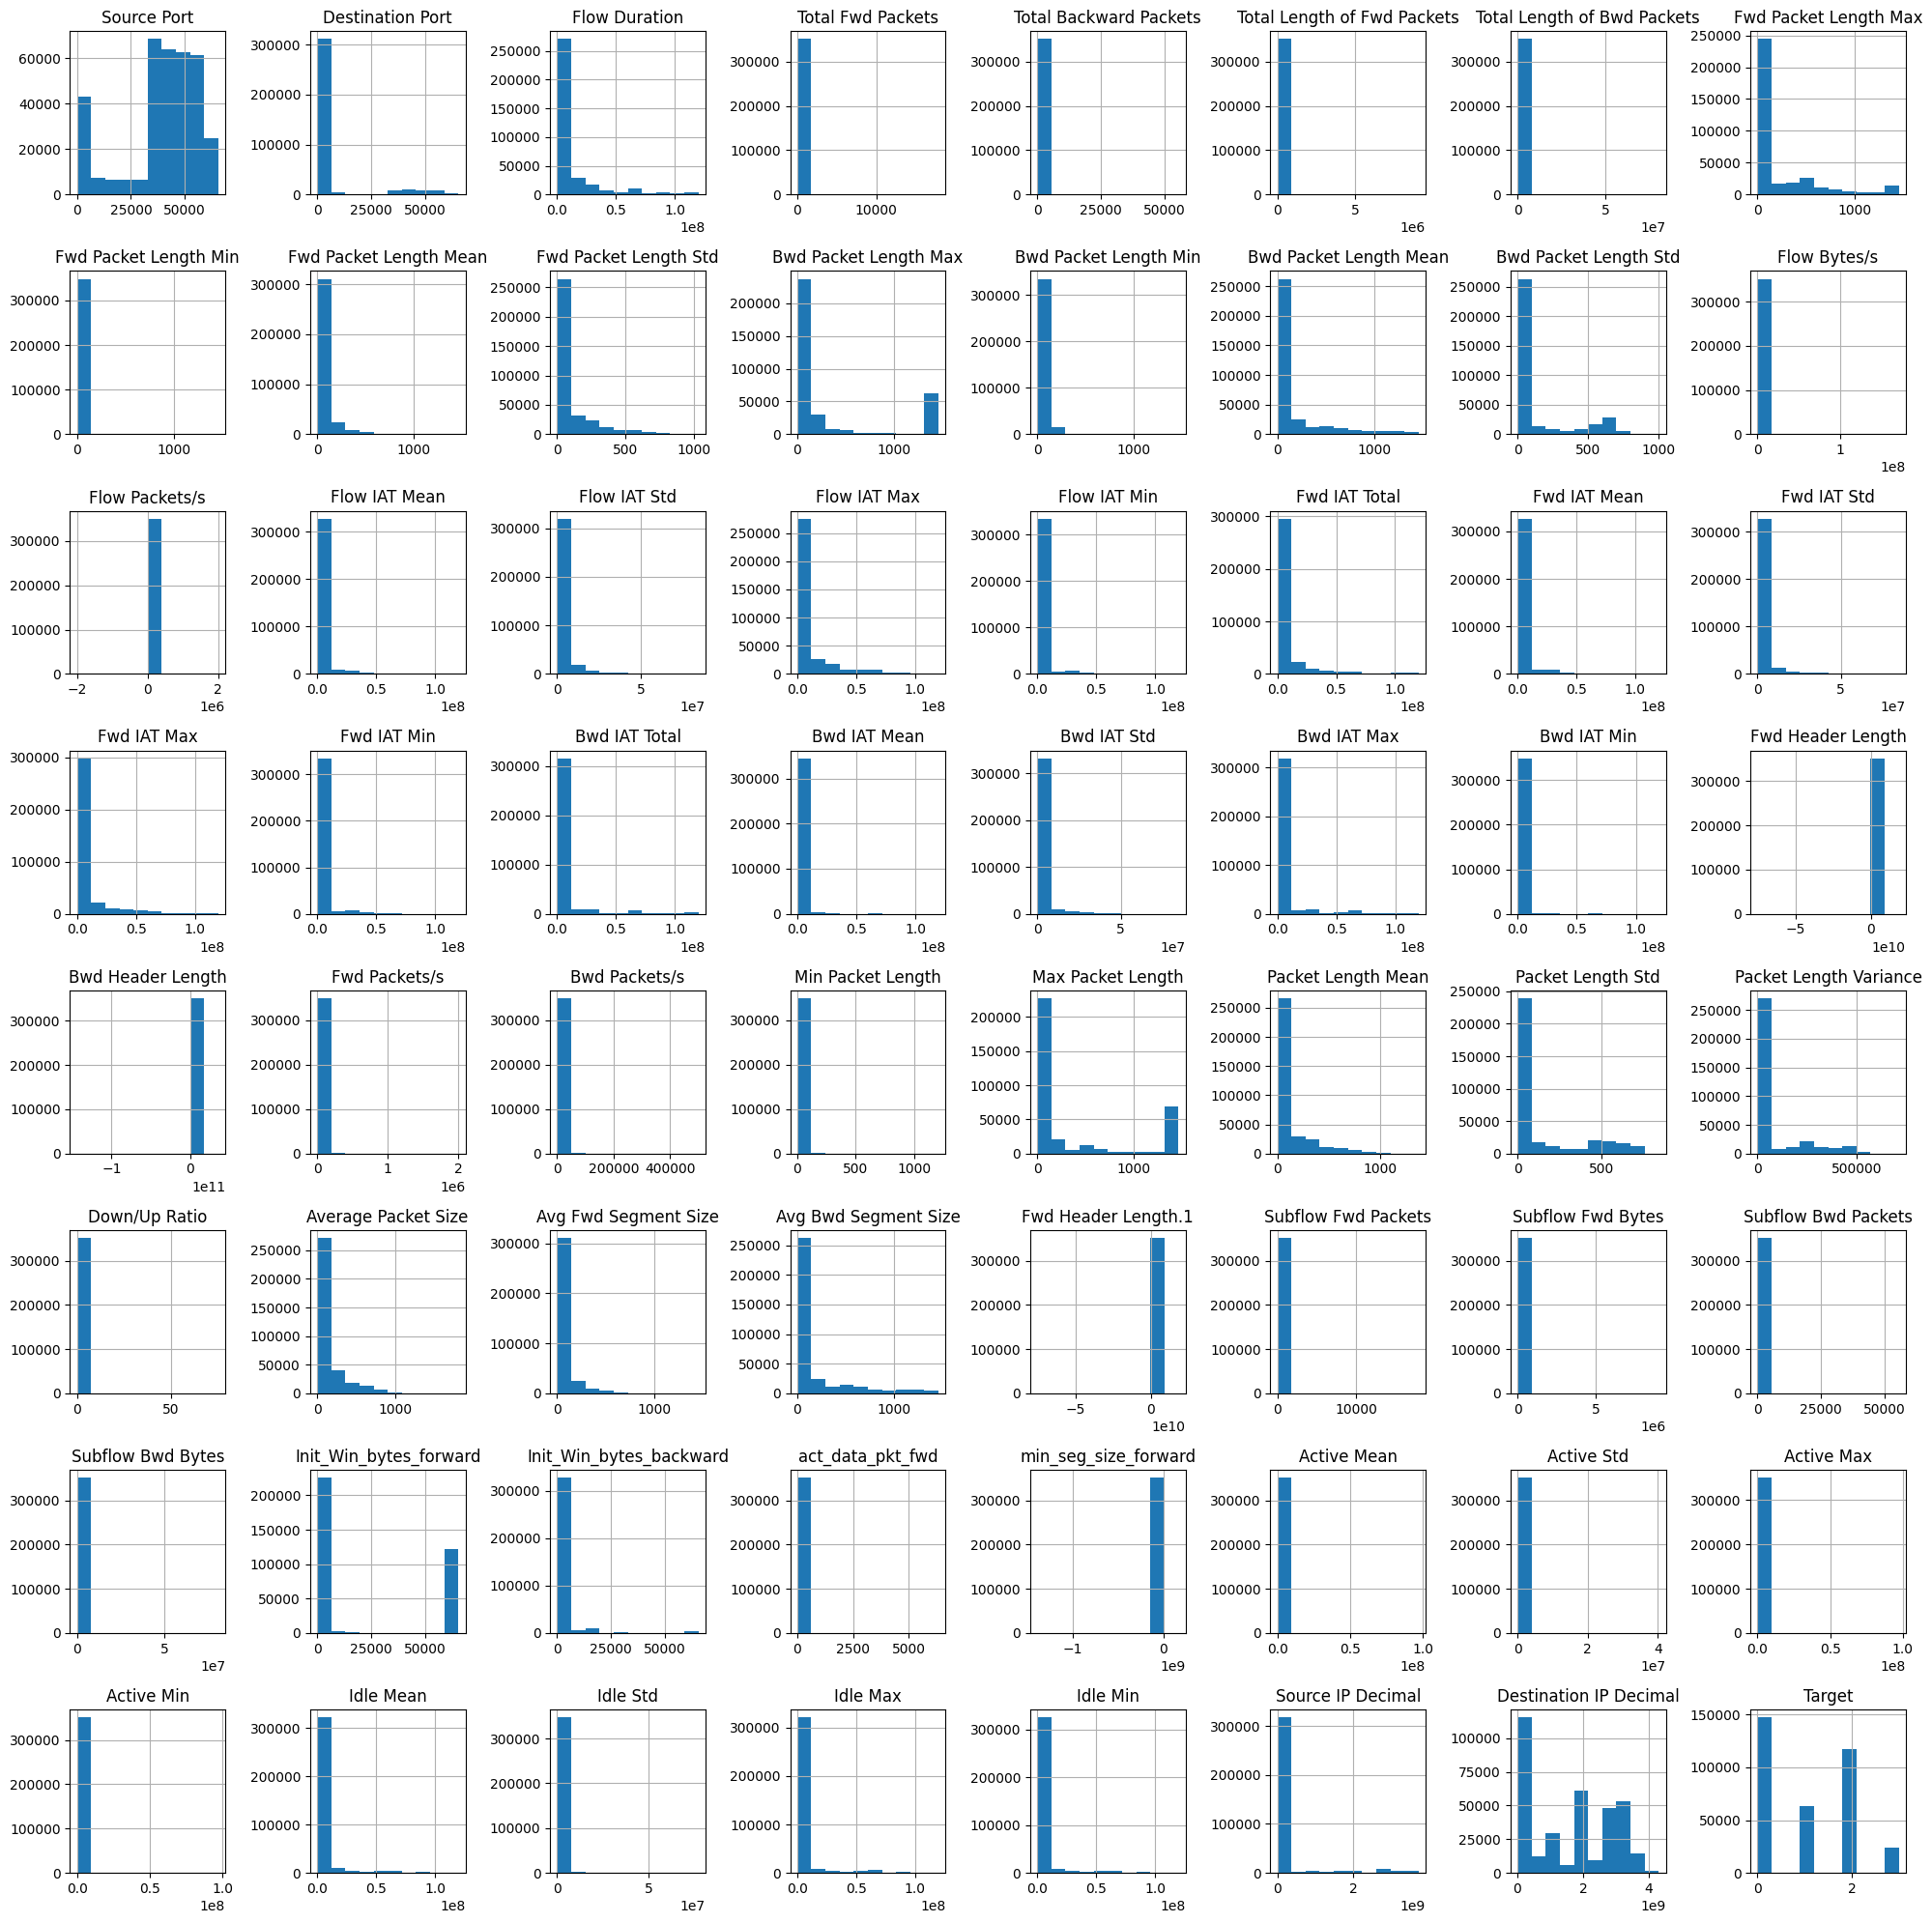

In [ ]:
df.hist(figsize=(20, 20))
plt.tight_layout()
plt.show()

## 9.2 Seleksi Fitur Numerikal

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.drop('Target')

keep_num_features = set()
exclude_num_features = set()

for col in numeric_cols:
    significant = False
    classes = df['Target'].unique()
    for cls in classes:
        group_a = df.loc[df['Target'] == cls, col]
        group_b = df.loc[df['Target'] != cls, col]
        stat, p = mannwhitneyu(group_a, group_b)
        if p < 0.05:
            significant = True
            break
    if significant:
        keep_num_features.add(col)
    else:
        exclude_num_features.add(col)

print(f"Fitur numerik dipertahankan: {len(keep_num_features)}")
print(f"Fitur numerik dibuang: {len(exclude_num_features)}")
print("\nDibuang:", exclude_num_features)

Fitur numerik dipertahankan: 63
Fitur numerik dibuang: 0

Dibuang: set()


## 9.3 Seleksi Fitur Kategorikal

In [ ]:
object_cols = df.select_dtypes(include='object').columns

keep_cat_df = pd.DataFrame(columns=['Feature', 'Chi2 Statistic', 'p-value'])
exclude_cat_df = pd.DataFrame(columns=['Feature', 'Chi2 Statistic', 'p-value'])

for col in object_cols:
    contingency_table = pd.crosstab(df[col], df['Target'])
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    if p < 0.05:
        keep_cat_df = pd.concat([keep_cat_df, pd.DataFrame({'Feature': [col], 'Chi2 Statistic': [chi2], 'p-value': [p.round(5)]})], ignore_index=True)
    else:
        exclude_cat_df = pd.concat([exclude_cat_df, pd.DataFrame({'Feature': [col], 'Chi2 Statistic': [chi2], 'p-value': [p.round(3)]})], ignore_index=True)

print("Features to keep:")
print(keep_cat_df)
print("\nFeatures to exclude:")
print(exclude_cat_df)

Features to keep:
          Feature  Chi2 Statistic  p-value
0        Protocol      854.945411      0.0
1   Fwd PSH Flags     1084.991310      0.0
2  FIN Flag Count       55.964997      0.0
3  SYN Flag Count     1084.991310      0.0
4  PSH Flag Count      123.211835      0.0
5  ACK Flag Count      183.983814      0.0
6  URG Flag Count      141.325123      0.0

Features to exclude:
Empty DataFrame
Columns: [Feature, Chi2 Statistic, p-value]
Index: []


# **10. Memisahkan Fitur (X) dan Target (y)**

In [ ]:
keep_features = list(keep_num_features) + list(keep_cat_df.Feature)

targ_var = 'Target'
X = df[keep_features]
y = df[targ_var]

print(f"Shape X: {X.shape}")
print(f"Jumlah kelas: {y.nunique()}")

Shape X: (351481, 70)
Jumlah kelas: 4


# 10.1 Mutual Information Post-Cleaning

Menghitung Mutual Information terhadap target...

  TOP 20 FITUR — MUTUAL INFORMATION (Post-Cleaning)
Rank   Feature                                  MI Score
-------------------------------------------------------
1      Destination IP Decimal                   0.216498
2      Source Port                              0.155070
3      Source IP Decimal                        0.110623
4      Packet Length Mean                       0.063805
5      Subflow Bwd Bytes                        0.062261
6      Avg Bwd Segment Size                     0.061932
7      Average Packet Size                      0.061486
8      Total Length of Bwd Packets              0.060857
9      Bwd Packet Length Mean                   0.060726
10     Packet Length Variance                   0.057977
11     Flow Duration                            0.056722
12     Packet Length Std                        0.056232
13     Flow IAT Max                             0.055508
14     Flow IAT Mean                        

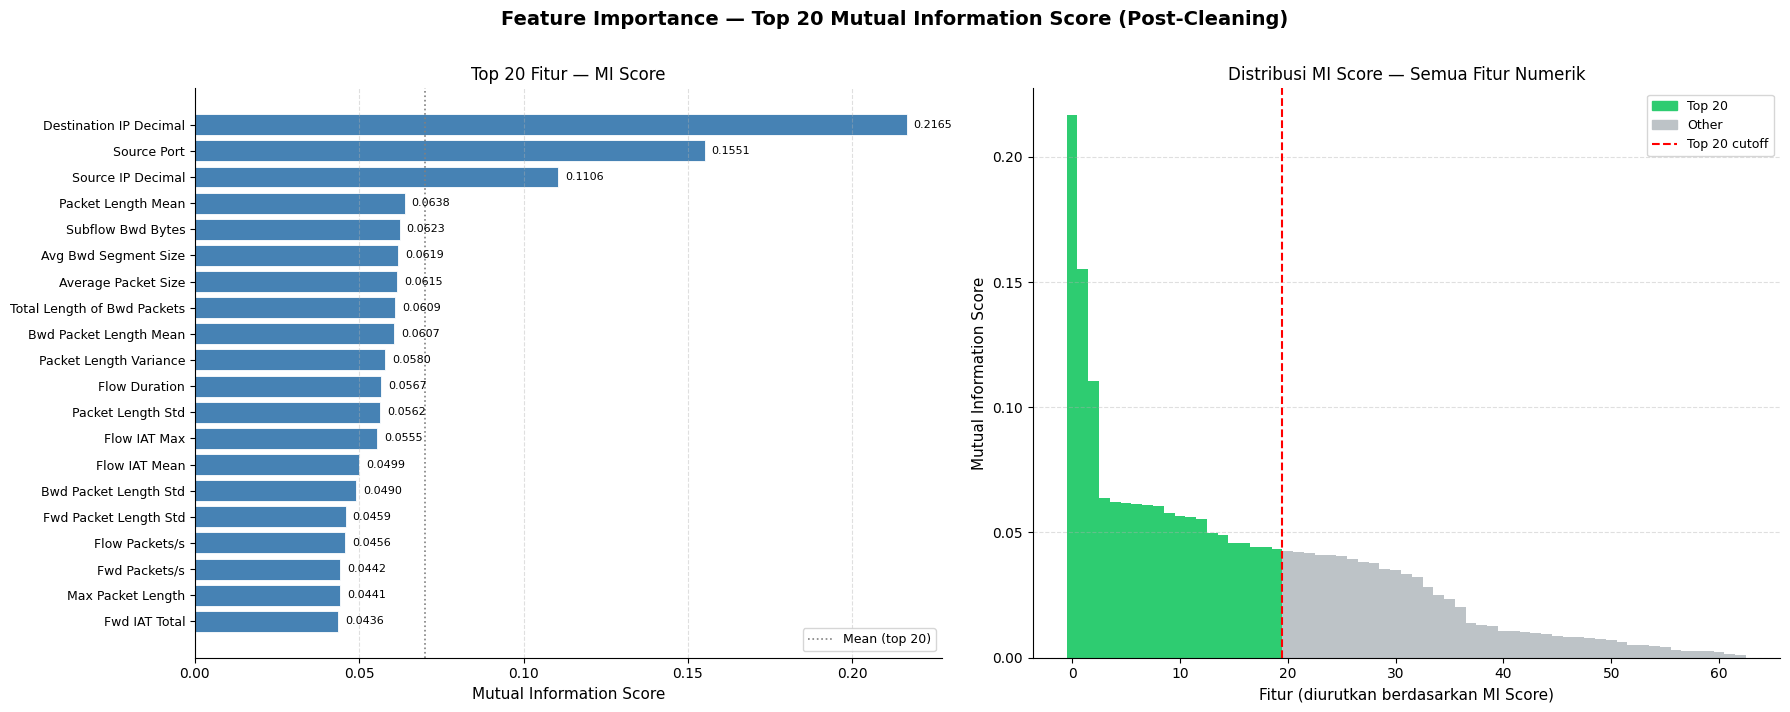

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TOP_N = 20

num_cols_fs = X.select_dtypes(include='number').columns.tolist()

X_num_fs = X[num_cols_fs].values.astype(float)
X_num_fs = np.where(np.isinf(X_num_fs), np.nan, X_num_fs)
X_num_fs = SimpleImputer(strategy='median').fit_transform(X_num_fs)

# Drop kolom zero-variance
var_mask = X_num_fs.var(axis=0) > 0
X_num_fs_clean = X_num_fs[:, var_mask]
clean_cols_fs  = [c for c, v in zip(num_cols_fs, var_mask) if v]

if var_mask.sum() < len(num_cols_fs):
    dropped = [c for c, v in zip(num_cols_fs, var_mask) if not v]
    print(f"[INFO] {len(dropped)} kolom zero-variance di-skip: {dropped}")

print("Menghitung Mutual Information terhadap target...")
mi_scores = mutual_info_classif(X_num_fs_clean, y, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({
    'Feature' : clean_cols_fs,
    'MI Score': mi_scores.round(6)
}).sort_values('MI Score', ascending=False).reset_index(drop=True)
mi_df.index += 1

top20_mi = mi_df.head(TOP_N)

print(f"\n{'='*55}")
print(f"  TOP {TOP_N} FITUR — MUTUAL INFORMATION (Post-Cleaning)")
print(f"{'='*55}")
print(f"{'Rank':<6} {'Feature':<38} {'MI Score':>10}")
print("-" * 55)
for rank, row in top20_mi.iterrows():
    print(f"{rank:<6} {row['Feature']:<38} {row['MI Score']:>10.6f}")
print("-" * 55)
print(f"Total fitur numerik dianalisis : {len(clean_cols_fs)}")
print(f"Rata-rata MI Score             : {mi_scores.mean():.6f}")
print(f"Fitur dengan MI < 0.01         : {(mi_scores < 0.01).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    f'Feature Importance — Top {TOP_N} Mutual Information Score (Post-Cleaning)',
    fontsize=14, fontweight='bold', y=1.01
)

palette = plt.cm.RdYlGn(np.linspace(0.2, 0.9, TOP_N))[::-1]
bars = axes[0].barh(
    top20_mi['Feature'][::-1],
    top20_mi['MI Score'][::-1],
    color='steelblue', edgecolor='white', linewidth=0.6
)
for bar, score in zip(bars, top20_mi['MI Score'][::-1]):
    axes[0].text(
        bar.get_width() + top20_mi['MI Score'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.4f}', va='center', ha='left', fontsize=8
    )
axes[0].set_xlabel('Mutual Information Score', fontsize=11)
axes[0].set_title(f'Top {TOP_N} Fitur — MI Score', fontsize=12)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0].axvline(top20_mi['MI Score'].mean(), color='gray',
                linestyle=':', linewidth=1.2, label='Mean (top 20)')
axes[0].legend(fontsize=9)

sorted_all = mi_df['MI Score'].values
colors_all = ['#2ecc71' if i < TOP_N else '#bdc3c7' for i in range(len(sorted_all))]
axes[1].bar(range(len(sorted_all)), sorted_all, color=colors_all, width=1.0, edgecolor='none')
axes[1].axvline(TOP_N - 0.5, color='red', linestyle='--', linewidth=1.5, label=f'Top {TOP_N} cutoff')
axes[1].set_xlabel('Fitur (diurutkan berdasarkan MI Score)', fontsize=11)
axes[1].set_ylabel('Mutual Information Score', fontsize=11)
axes[1].set_title('Distribusi MI Score — Semua Fitur Numerik', fontsize=12)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
selected_patch = mpatches.Patch(color='#2ecc71', label=f'Top {TOP_N}')
rest_patch     = mpatches.Patch(color='#bdc3c7', label='Other')
axes[1].legend(handles=[selected_patch, rest_patch, axes[1].lines[0]], fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_MI.png', bbox_inches='tight', dpi=150)
plt.show()

# **11. Import Library Machine Learning**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, fbeta_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
from tqdm import tqdm

# **12. Split Data & Definisi Jenis Kolom**

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definisi jenis kolom
categorical_cols = [c for c in ['Protocol', 'PSH Flag Count', 'ACK Flag Count'] if c in keep_features]
numeric_cols = [c for c in keep_features if c not in categorical_cols]


# **13. Inisialisasi Random Forest, XGBoost, dan Linear SVM**

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

classifiers = [
    ('RandomForestClassifier', RandomForestClassifier(random_state=42)),
    ('XGBClassifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')),
    ('SVMLinearClassifier', CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000)))
]

# **14. Konfigurasi Preprocessor, Sampler, dan Metrik**

In [ ]:
# Preprocessor StandardScaler
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
], remainder='passthrough')

# Sampler
sampler = SMOTE(random_state=42)

# Metrik
scoring = {
    'fbeta': make_scorer(fbeta_score, beta=2, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted'),
    'accuracy': make_scorer(accuracy_score)
}

# **15. Proses Training dengan Cross-Validation & Simpan Model Terbaik**

Classifier:  33%|███▎      | 1/3 [47:30<1:35:00, 2850.44s/it]/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:11:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Classifier,CV F2 Score,CV F1,CV Recall,CV Precision,CV Accuracy
0,RandomForestClassifier,0.584569,0.584046,0.585026,0.583633,0.585026
1,XGBClassifier,0.562837,0.564194,0.563087,0.572378,0.563087
2,SVMLinearClassifier,0.312462,0.321299,0.313990,0.368215,0.313990



=== CONFUSION MATRIX TIAP MODEL ===


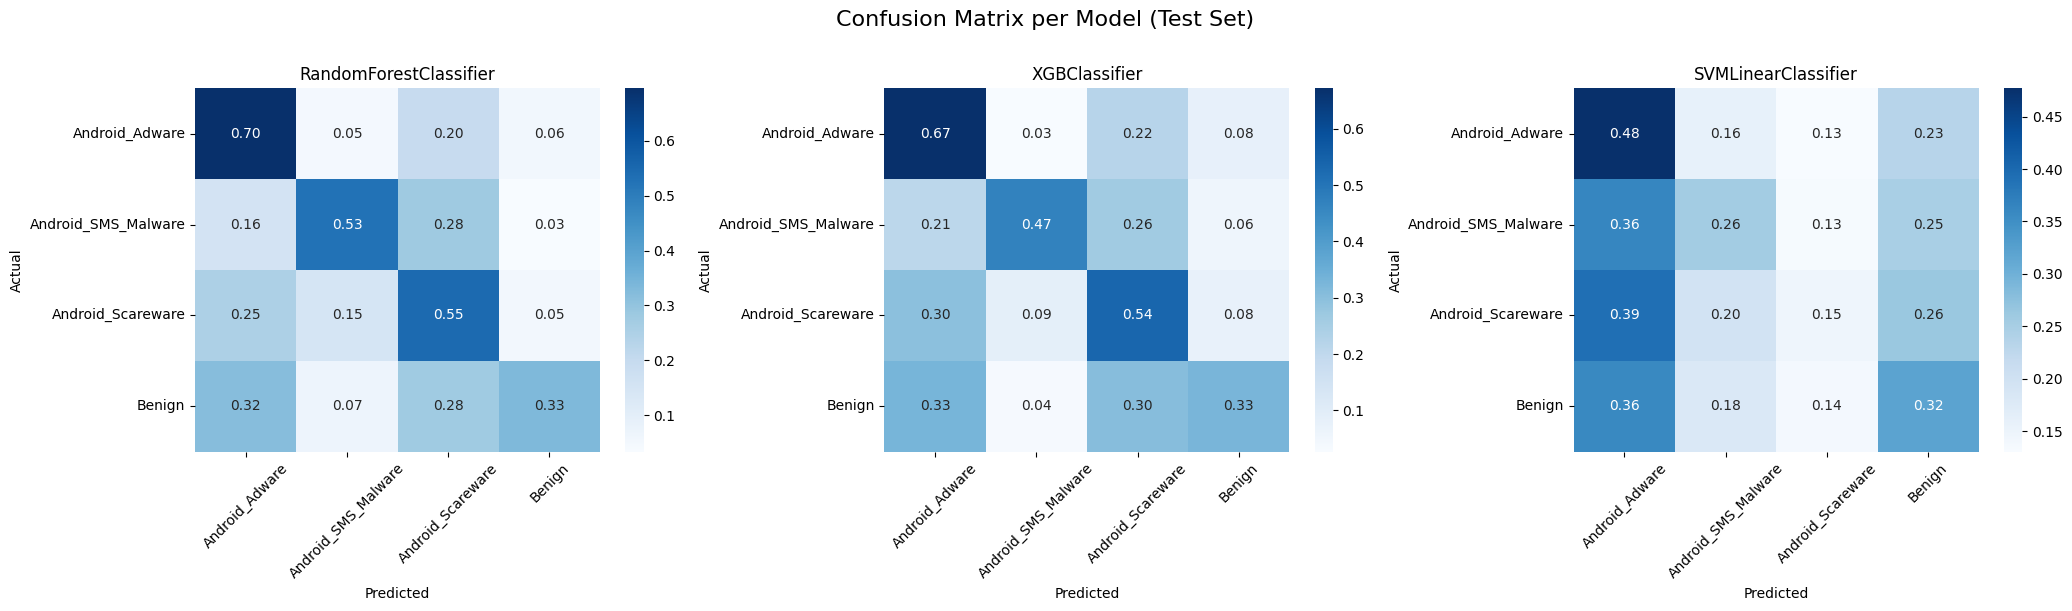

Confusion matrix per model telah disimpan.


In [ ]:
best_pipeline = None
best_score = -np.inf
results = []
trained_pipelines = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for clf_name, classifier in tqdm(classifiers, desc='Classifier', leave=False):
    pipeline = make_pipeline(preprocessor, sampler, classifier)
    cv_scores = cross_validate(pipeline, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1)

    results.append({
        'Classifier': clf_name,
        'CV F2 Score': np.mean(cv_scores['test_fbeta']),
        'CV F1': np.mean(cv_scores['test_f1']),
        'CV Recall': np.mean(cv_scores['test_recall']),
        'CV Precision': np.mean(cv_scores['test_precision']),
        'CV Accuracy': np.mean(cv_scores['test_accuracy'])
    })

    if np.mean(cv_scores['test_fbeta']) > best_score:
        best_score = np.mean(cv_scores['test_fbeta'])
        best_pipeline = pipeline

    # Fit pipeline dan simpan untuk confusion matrix
    pipeline.fit(X_train, y_train)
    trained_pipelines[clf_name] = pipeline

best_pipeline.fit(X_train, y_train)
joblib.dump(best_pipeline, 'best_pipeline.pkl')

results_df = pd.DataFrame(results)
display(results_df.sort_values('CV F2 Score', ascending=False))

# Confusion Matrix
print("\n=== CONFUSION MATRIX TIAP MODEL ===")
class_names = le.classes_
n_models = len(trained_pipelines)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
fig.suptitle("Confusion Matrix per Model (Test Set)", fontsize=16, y=1.01)

if n_models == 1:
    axes = [axes]

for ax, (clf_name, pipe) in zip(axes, trained_pipelines.items()):
    y_pred_cm = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_cm, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(clf_name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix_per_model.png', bbox_inches='tight')
plt.show()
print("Confusion matrix per model telah disimpan.")

In [ ]:
# Classification Report
print("=== LAPORAN KLASIFIKASI TIAP MODEL ===")
class_names = le.classes_

for clf_name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    print("" + "="*60)
    print("Laporan Klasifikasi (" + clf_name + "):")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


=== LAPORAN KLASIFIKASI TIAP MODEL ===

Laporan Klasifikasi (RandomForestClassifier):
                     precision    recall  f1-score   support

     Android_Adware       0.69      0.70      0.69     29486
Android_SMS_Malware       0.57      0.53      0.55     12658
  Android_Scareware       0.54      0.55      0.55     23411
             Benign       0.33      0.33      0.33      4742

           accuracy                           0.59     70297
          macro avg       0.53      0.53      0.53     70297
       weighted avg       0.59      0.59      0.59     70297


Laporan Klasifikasi (XGBClassifier):
                     precision    recall  f1-score   support

     Android_Adware       0.64      0.67      0.65     29486
Android_SMS_Malware       0.65      0.47      0.55     12658
  Android_Scareware       0.53      0.53      0.53     23411
             Benign       0.24      0.34      0.28      4742

           accuracy                           0.57     70297
          macro a

# **16. FLAML**

In [ ]:
!pip install flaml[automl] -q

In [ ]:
from flaml import AutoML
from sklearn.metrics import classification_report, fbeta_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

In [ ]:
preprocessor_flaml = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
], remainder='passthrough')

X_train_prep_flaml = preprocessor_flaml.fit_transform(X_train)
X_test_prep_flaml  = preprocessor_flaml.transform(X_test)


smote_flaml = SMOTE(random_state=42)
X_train_resampled_flaml, y_train_resampled_flaml = smote_flaml.fit_resample(X_train_prep_flaml, y_train)

print(f"Shape X_train setelah preprocessing + SMOTE: {X_train_resampled_flaml.shape}")
print(f"Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train_resampled_flaml).value_counts())

def f1_weighted_metric(X_val, y_val, estimator, labels, X_train, y_train,
                       weight_val=None, weight_train=None, *args):
    from sklearn.metrics import f1_score as _f1
    y_pred = estimator.predict(X_val)
    val_loss   = 1 - _f1(y_val,   y_pred, average="weighted")
    y_pred_tr  = estimator.predict(X_train)
    train_loss = 1 - _f1(y_train, y_pred_tr, average="weighted")
    return val_loss, {"val_loss": val_loss, "train_loss": train_loss}

automl = AutoML()

automl_settings = {
    "time_budget": 3600,
    "metric": f1_weighted_metric,
    "task": "classification",
    "eval_method": "cv",
    "n_splits": 5,
    "split_type": "stratified",
    "seed": 42,
    "verbose": 2,
    "early_stop": True,
    "skip_transform": True,
    "log_file_name": "flaml.log",
}

print("\nMemulai pencarian model terbaik dengan FLAML...")
automl.fit(X_train_resampled_flaml, y_train_resampled_flaml, **automl_settings)

print(f"\n=== HASIL OPTIMASI FLAML ===")
print(f"Model terbaik FLAML : {automl.best_estimator}")
print(f"Best config         : {automl.best_config}")
print(f"Best CV loss        : {automl.best_loss:.4f}")

y_pred_flaml = automl.predict(X_test_prep_flaml)

print("\nLaporan Klasifikasi (FLAML):")
print(classification_report(y_test, y_pred_flaml, target_names=le.classes_))

results_flaml = {
    'Best Model (FLAML)': automl.best_estimator,
    'F2 Score': fbeta_score(y_test, y_pred_flaml, beta=2, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_flaml, average='weighted'),
    'Recall': recall_score(y_test, y_pred_flaml, average='weighted'),
    'Precision': precision_score(y_test, y_pred_flaml, average='weighted', zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_flaml),
}
display(pd.DataFrame([results_flaml]))


Shape X_train setelah preprocessing + SMOTE: (471764, 74)
Distribusi kelas setelah SMOTE:
Target
3    117941
0    117941
2    117941
1    117941
Name: count, dtype: int64

Memulai pencarian model terbaik dengan FLAML...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


=== HASIL OPTIMASI FLAML ===
Model terbaik FLAML : lgbm
Best config         : {'n_estimators': 527, 'num_leaves': 12, 'min_child_samples': 16, 'learning_rate': 1.0, 'log_max_bin': 6, 'colsample_bytree': 1.0, 'reg_alpha': np.float64(0.007469466171857912), 'reg_lambda': np.float64(19.521592093366618)}
Best CV loss        : 0.3286


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Laporan Klasifikasi (FLAML):
                     precision    recall  f1-score   support

     Android_Adware       0.67      0.71      0.69     29486
Android_SMS_Malware       0.64      0.53      0.58     12658
  Android_Scareware       0.56      0.55      0.56     23411
             Benign       0.31      0.36      0.34      4742

           accuracy                           0.60     70297
          macro avg       0.54      0.54      0.54     70297
       weighted avg       0.60      0.60      0.60     70297



,Best Model (FLAML),F2 Score,F1 Score,Recall,Precision,Accuracy
0,lgbm,0.600435,0.600731,0.60068,0.603193,0.60068


=== CONFUSION MATRIX - BEST MODEL FLAML (lgbm) ===


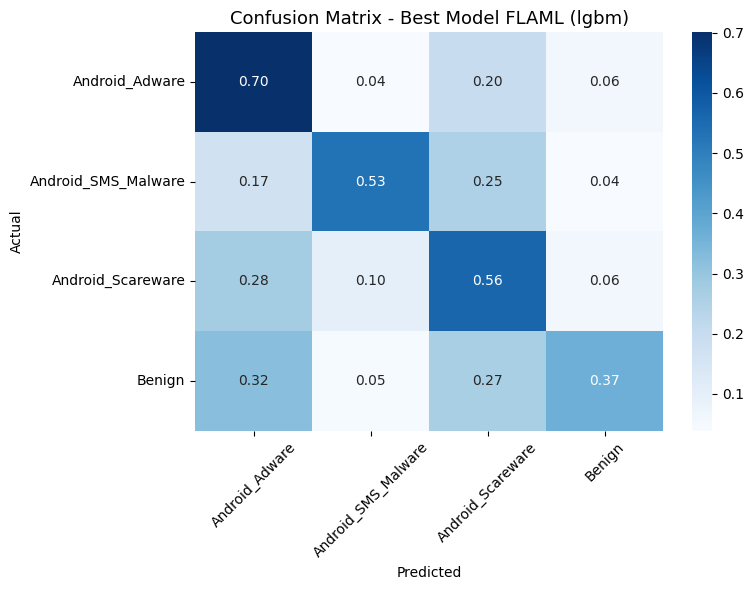

Confusion matrix FLAML best model telah disimpan.


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = le.classes_
best_flaml_name = automl.best_estimator
cm_flaml = confusion_matrix(y_test, y_pred_flaml, normalize="true")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_flaml, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - Best Model FLAML (" + best_flaml_name + ")", fontsize=13)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_flaml_best.png", bbox_inches="tight")
plt.show()
print("Confusion matrix FLAML best model telah disimpan.")


# **17. AutoGluon**

In [ ]:
!pip install autogluon -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.5 MB/s eta 0:00

In [ ]:
from autogluon.tabular import TabularPredictor
from sklearn.metrics import classification_report, fbeta_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE


In [ ]:
preprocessor_ag = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
], remainder='passthrough')

X_train_prep_ag = preprocessor_ag.fit_transform(X_train)
X_test_prep_ag  = preprocessor_ag.transform(X_test)

smote_ag = SMOTE(random_state=42)
X_train_resampled_ag, y_train_resampled_ag = smote_ag.fit_resample(X_train_prep_ag, y_train)

print(f"Shape X_train setelah preprocessing + SMOTE: {X_train_resampled_ag.shape}")
print(f"Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train_resampled_ag).value_counts())

feature_names_out = preprocessor_ag.get_feature_names_out()
train_ag = pd.DataFrame(X_train_resampled_ag, columns=feature_names_out)
train_ag['Target'] = y_train_resampled_ag.values

test_ag = pd.DataFrame(X_test_prep_ag, columns=feature_names_out)

print("\nMemulai training dengan AutoGluon...")
predictor = TabularPredictor(
    label='Target',
    path='ag_models_multiclass/',
    eval_metric='f1_weighted',
    problem_type='multiclass'
).fit(
    train_data=train_ag,
    time_limit=3600,
    presets='best_quality',
    verbosity=2
)

print(f"\n=== HASIL OPTIMASI AUTOGLUON ===")
print(f"Model terbaik : {predictor.get_model_best()}")

print("\n=== LEADERBOARD MODEL AUTOGLUON ===")
leaderboard = predictor.leaderboard(test_ag.assign(Target=y_test.values), silent=False)
display(leaderboard)

y_pred_ag = predictor.predict(test_ag)

print("\nLaporan Klasifikasi (AutoGluon):")
print(classification_report(y_test, y_pred_ag, target_names=le.classes_))

results_ag = {
    'Best Model (AutoGluon)': predictor.get_model_best(),
    'F2 Score': fbeta_score(y_test, y_pred_ag, beta=2, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_ag, average='weighted'),
    'Recall': recall_score(y_test, y_pred_ag, average='weighted'),
    'Precision': precision_score(y_test, y_pred_ag, average='weighted', zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_ag),
}
display(pd.DataFrame([results_ag]))


Verbosity: 2 (Standard Logging)


Shape X_train setelah preprocessing + SMOTE: (471764, 74)
Distribusi kelas setelah SMOTE:
Target
3    117941
0    117941
2    117941
1    117941
Name: count, dtype: int64

Memulai training dengan AutoGluon...


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       9.74 GB / 12.67 GB (76.9%)
Disk Space Avail:   75.61 GB / 107.72 GB (70.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will b


=== HASIL OPTIMASI AUTOGLUON ===


AttributeError: 'TabularPredictor' object has no attribute 'get_model_best'

In [ ]:
print(f"\n=== HASIL OPTIMASI AUTOGLUON ===")
print(f"Model terbaik : {predictor.model_best}")

print("\n=== LEADERBOARD MODEL AUTOGLUON ===")
leaderboard = predictor.leaderboard(test_ag.assign(Target=y_test.values), silent=False)
display(leaderboard)

y_pred_ag = predictor.predict(test_ag)

print("\nLaporan Klasifikasi (AutoGluon):")
print(classification_report(y_test, y_pred_ag, target_names=le.classes_))

results_ag = {
    'Best Model (AutoGluon)': predictor.model_best,
    'F2 Score': fbeta_score(y_test, y_pred_ag, beta=2, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_ag, average='weighted'),
    'Recall': recall_score(y_test, y_pred_ag, average='weighted'),
    'Precision': precision_score(y_test, y_pred_ag, average='weighted', zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_ag),
}
display(pd.DataFrame([results_ag]))


=== HASIL OPTIMASI AUTOGLUON ===
Model terbaik : WeightedEnsemble_L3

=== LEADERBOARD MODEL AUTOGLUON ===
                    model  score_test  score_val  eval_metric  pred_time_test  pred_time_val     fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  NeuralNetFastAI_BAG_L2    0.517606   0.537101  f1_weighted       41.326968      55.054636  2357.164867                 9.172639               10.175222         578.312940            2       True          5
1     WeightedEnsemble_L3    0.517573   0.537126  f1_weighted       41.336494      55.194301  2377.138928                 0.009526                0.139665          19.974061            3       True          7
2       LightGBMXT_BAG_L2    0.511984   0.525092  f1_weighted       36.598347      53.105214  1996.481462                 4.444019                8.225799         217.629534            2       True          6
3     WeightedEnsemble_L2    0.500713   0.513721  f1_weig

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI_BAG_L2,0.517606,0.537101,f1_weighted,41.326968,55.054636,2357.164867,9.172639,10.175222,578.312940,2,True,5
1,WeightedEnsemble_L3,0.517573,0.537126,f1_weighted,41.336494,55.194301,2377.138928,0.009526,0.139665,19.974061,3,True,7
2,LightGBMXT_BAG_L2,0.511984,0.525092,f1_weighted,36.598347,53.105214,1996.481462,4.444019,8.225799,217.629534,2,True,6
3,WeightedEnsemble_L2,0.500713,0.513721,f1_weighted,32.172526,45.052519,1791.390715,0.018198,0.173104,12.538787,2,True,4
4,LightGBM_BAG_L1,0.498387,0.483144,f1_weighted,0.522457,1.127192,91.274848,0.522457,1.127192,91.274848,1,True,3
5,LightGBMXT_BAG_L1,0.489233,0.499372,f1_weighted,15.555879,32.116735,512.548836,15.555879,32.116735,512.548836,1,True,2
6,NeuralNetFastAI_BAG_L1,0.332399,0.363877,f1_weighted,16.075992,11.635489,1175.028244,16.075992,11.635489,1175.028244,1,True,1



Laporan Klasifikasi (AutoGluon):
                     precision    recall  f1-score   support

     Android_Adware       0.59      0.64      0.62     29486
Android_SMS_Malware       0.67      0.39      0.49     12658
  Android_Scareware       0.49      0.45      0.47     23411
             Benign       0.17      0.32      0.22      4742

           accuracy                           0.51     70297
          macro avg       0.48      0.45      0.45     70297
       weighted avg       0.54      0.51      0.52     70297



,Best Model (AutoGluon),F2 Score,F1 Score,Recall,Precision,Accuracy
0,WeightedEnsemble_L3,0.512636,0.517573,0.512255,0.540222,0.512255


=== CONFUSION MATRIX - BEST MODEL AUTOGLUON (WeightedEnsemble_L3) ===


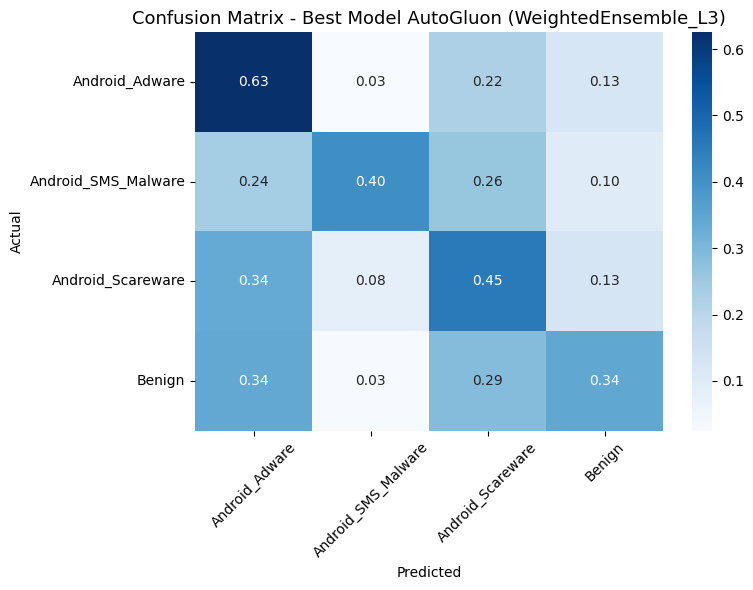

Confusion matrix AutoGluon best model telah disimpan.


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = le.classes_
best_ag_name = predictor.model_best
cm_ag = confusion_matrix(y_test, y_pred_ag, normalize="true")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_ag, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - Best Model AutoGluon (" + best_ag_name + ")", fontsize=13)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_autogluon_best.png", bbox_inches="tight")
plt.show()
print("Confusion matrix AutoGluon best model telah disimpan.")
